# Assignment 3:

Read the following articles:

https://www.hindawi.com/journals/complexity/2021/5550344/

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8137961/
    
    Search for academic content (at least 3 articles) that compare the use of decision trees vs SVMs in your current area of expertise.
    
    Perform an analysis of the dataset used in Homework #2 using the SVM algorithm.
    
    Compare the results with the results from previous homework.

    Answer questions, such as:
        Which algorithm is recommended to get more accurate results?
        Is it better for classification or regression scenarios?
        Do you agree with the recommendations?
        Why?

Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import randint, loguniform
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/stormwhale/data-mines/refs/heads/main/bank-additional-full.csv', sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


checking for missing values, and duplicates.

In [3]:
print('Number of missing values=', df.isnull().sum())
print('-'*80)
print('Number of duplicates=', df.duplicated().sum())

Number of missing values= age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
--------------------------------------------------------------------------------
Number of duplicates= 12


Let's eliminate the duplicates:

In [4]:
df = df.drop(df[df.duplicated()].index)
print('Number of duplicates=', df.duplicated().sum())

Number of duplicates= 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

Remove 'duration' column since it introduces data leakage:

In [6]:
df = df.drop('duration', axis=1)

Let's explore the relationships of the dataset:

In [7]:
cat_col = df.select_dtypes('object').columns.tolist()
num_col = df.select_dtypes(['int64', 'float64']).columns.tolist()

#Numerical column relationships:

Let's explore the relationship between all the columns using another method:

--------------------------------------------------------------------------------
Categorical columns:
--------------------------------------------------------------------------------
Numerical columns:
--------------------------------------------------------------------------------
Combined association plot. (Orange color highlights subscribed customers)


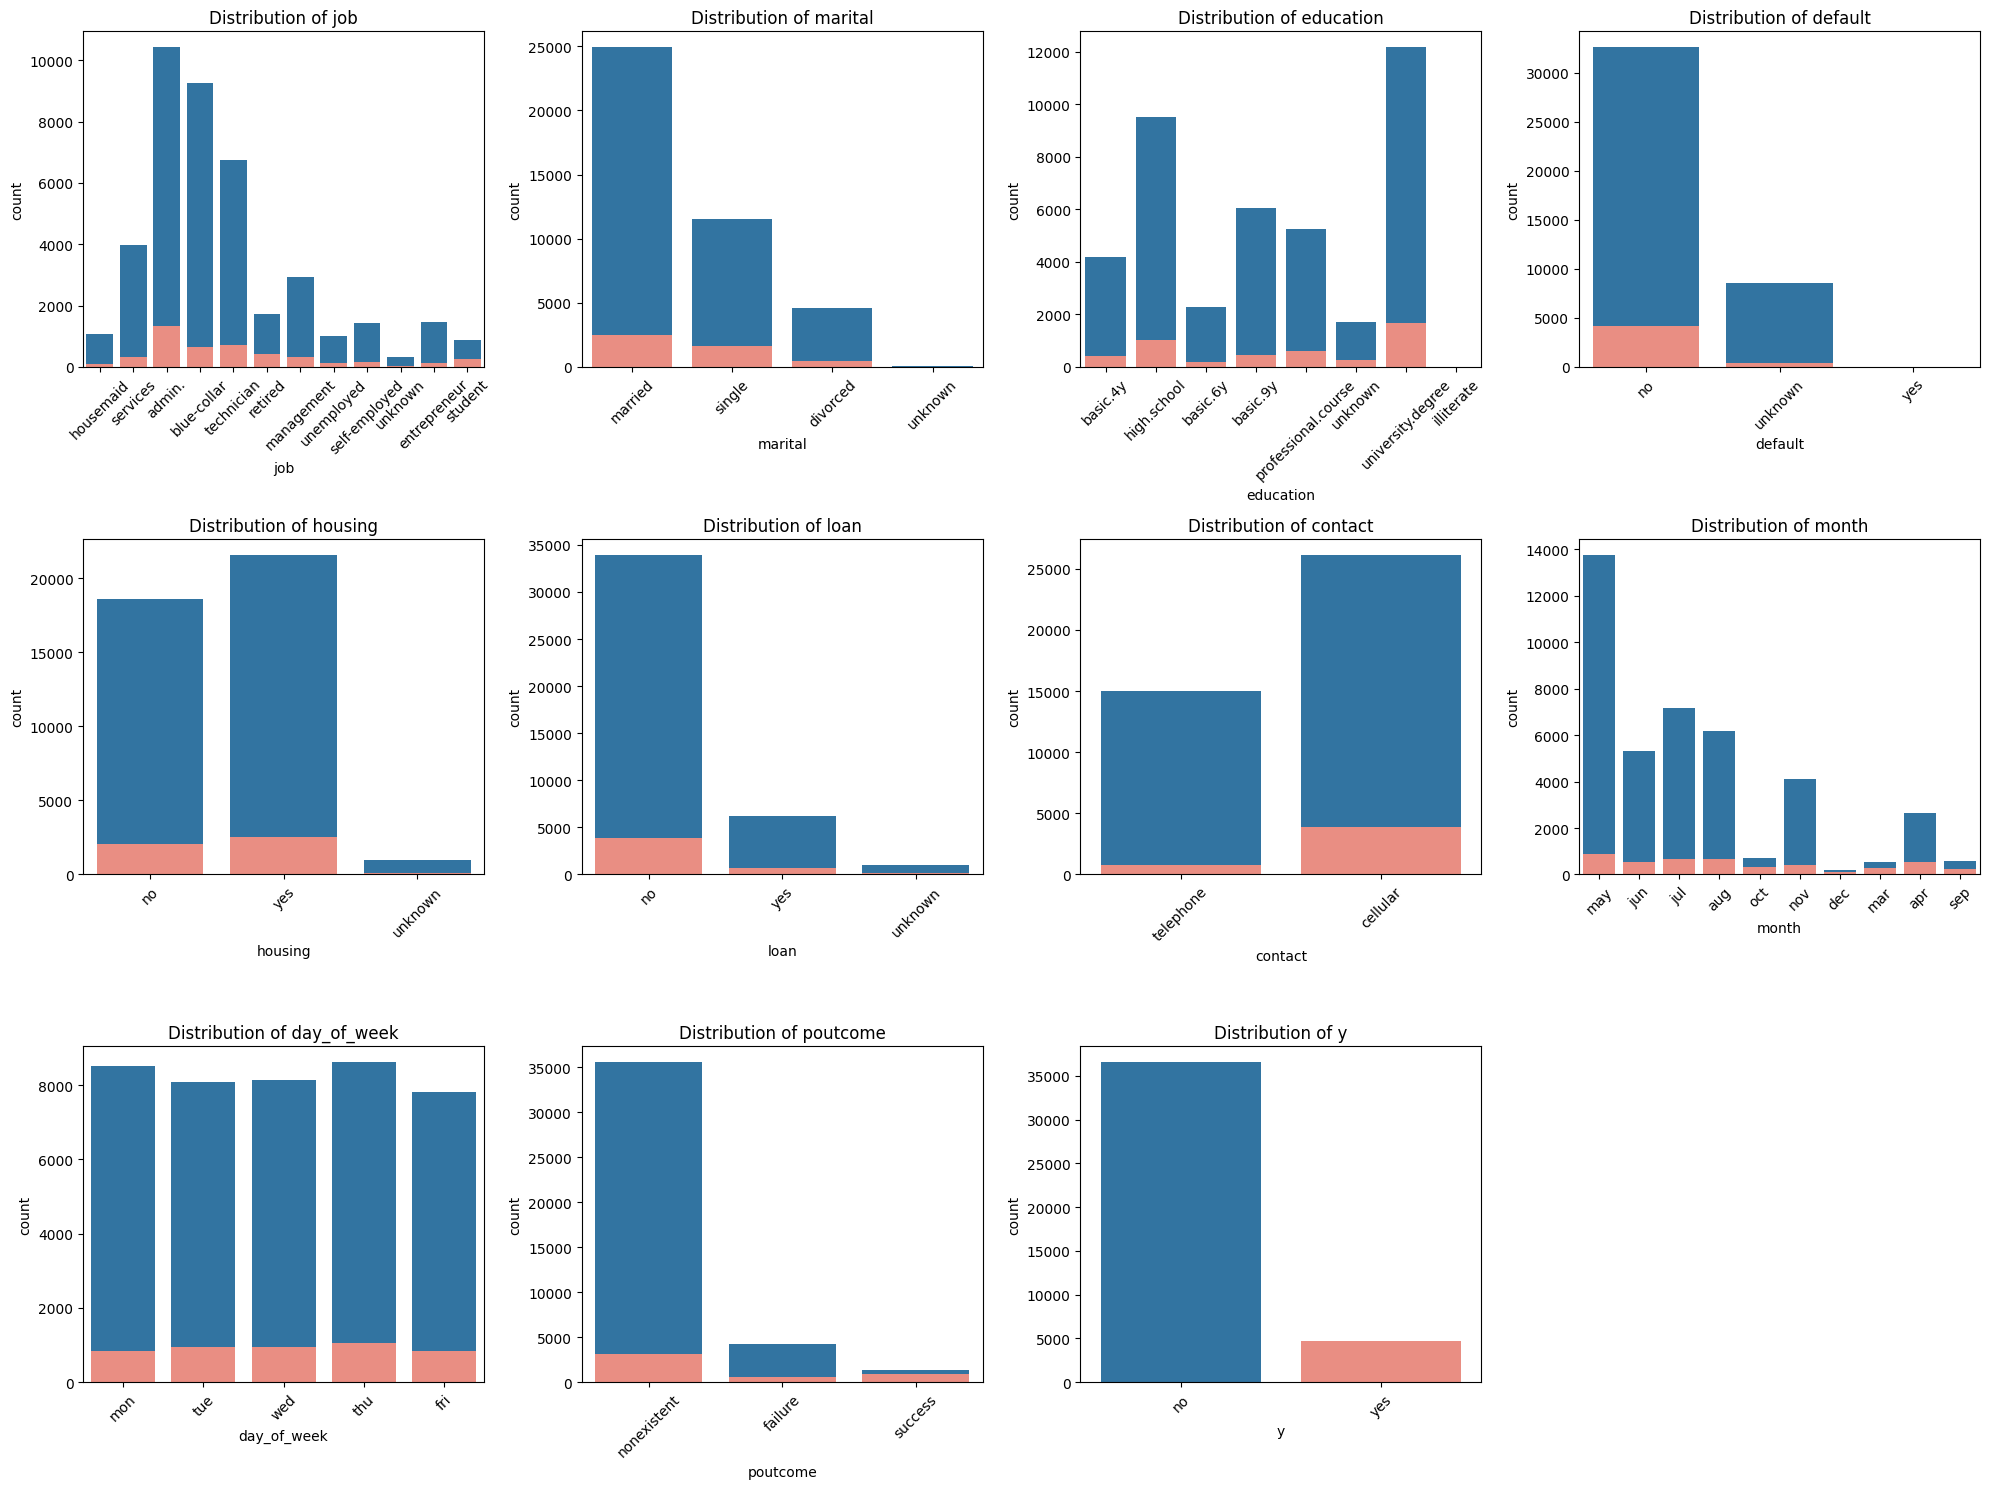

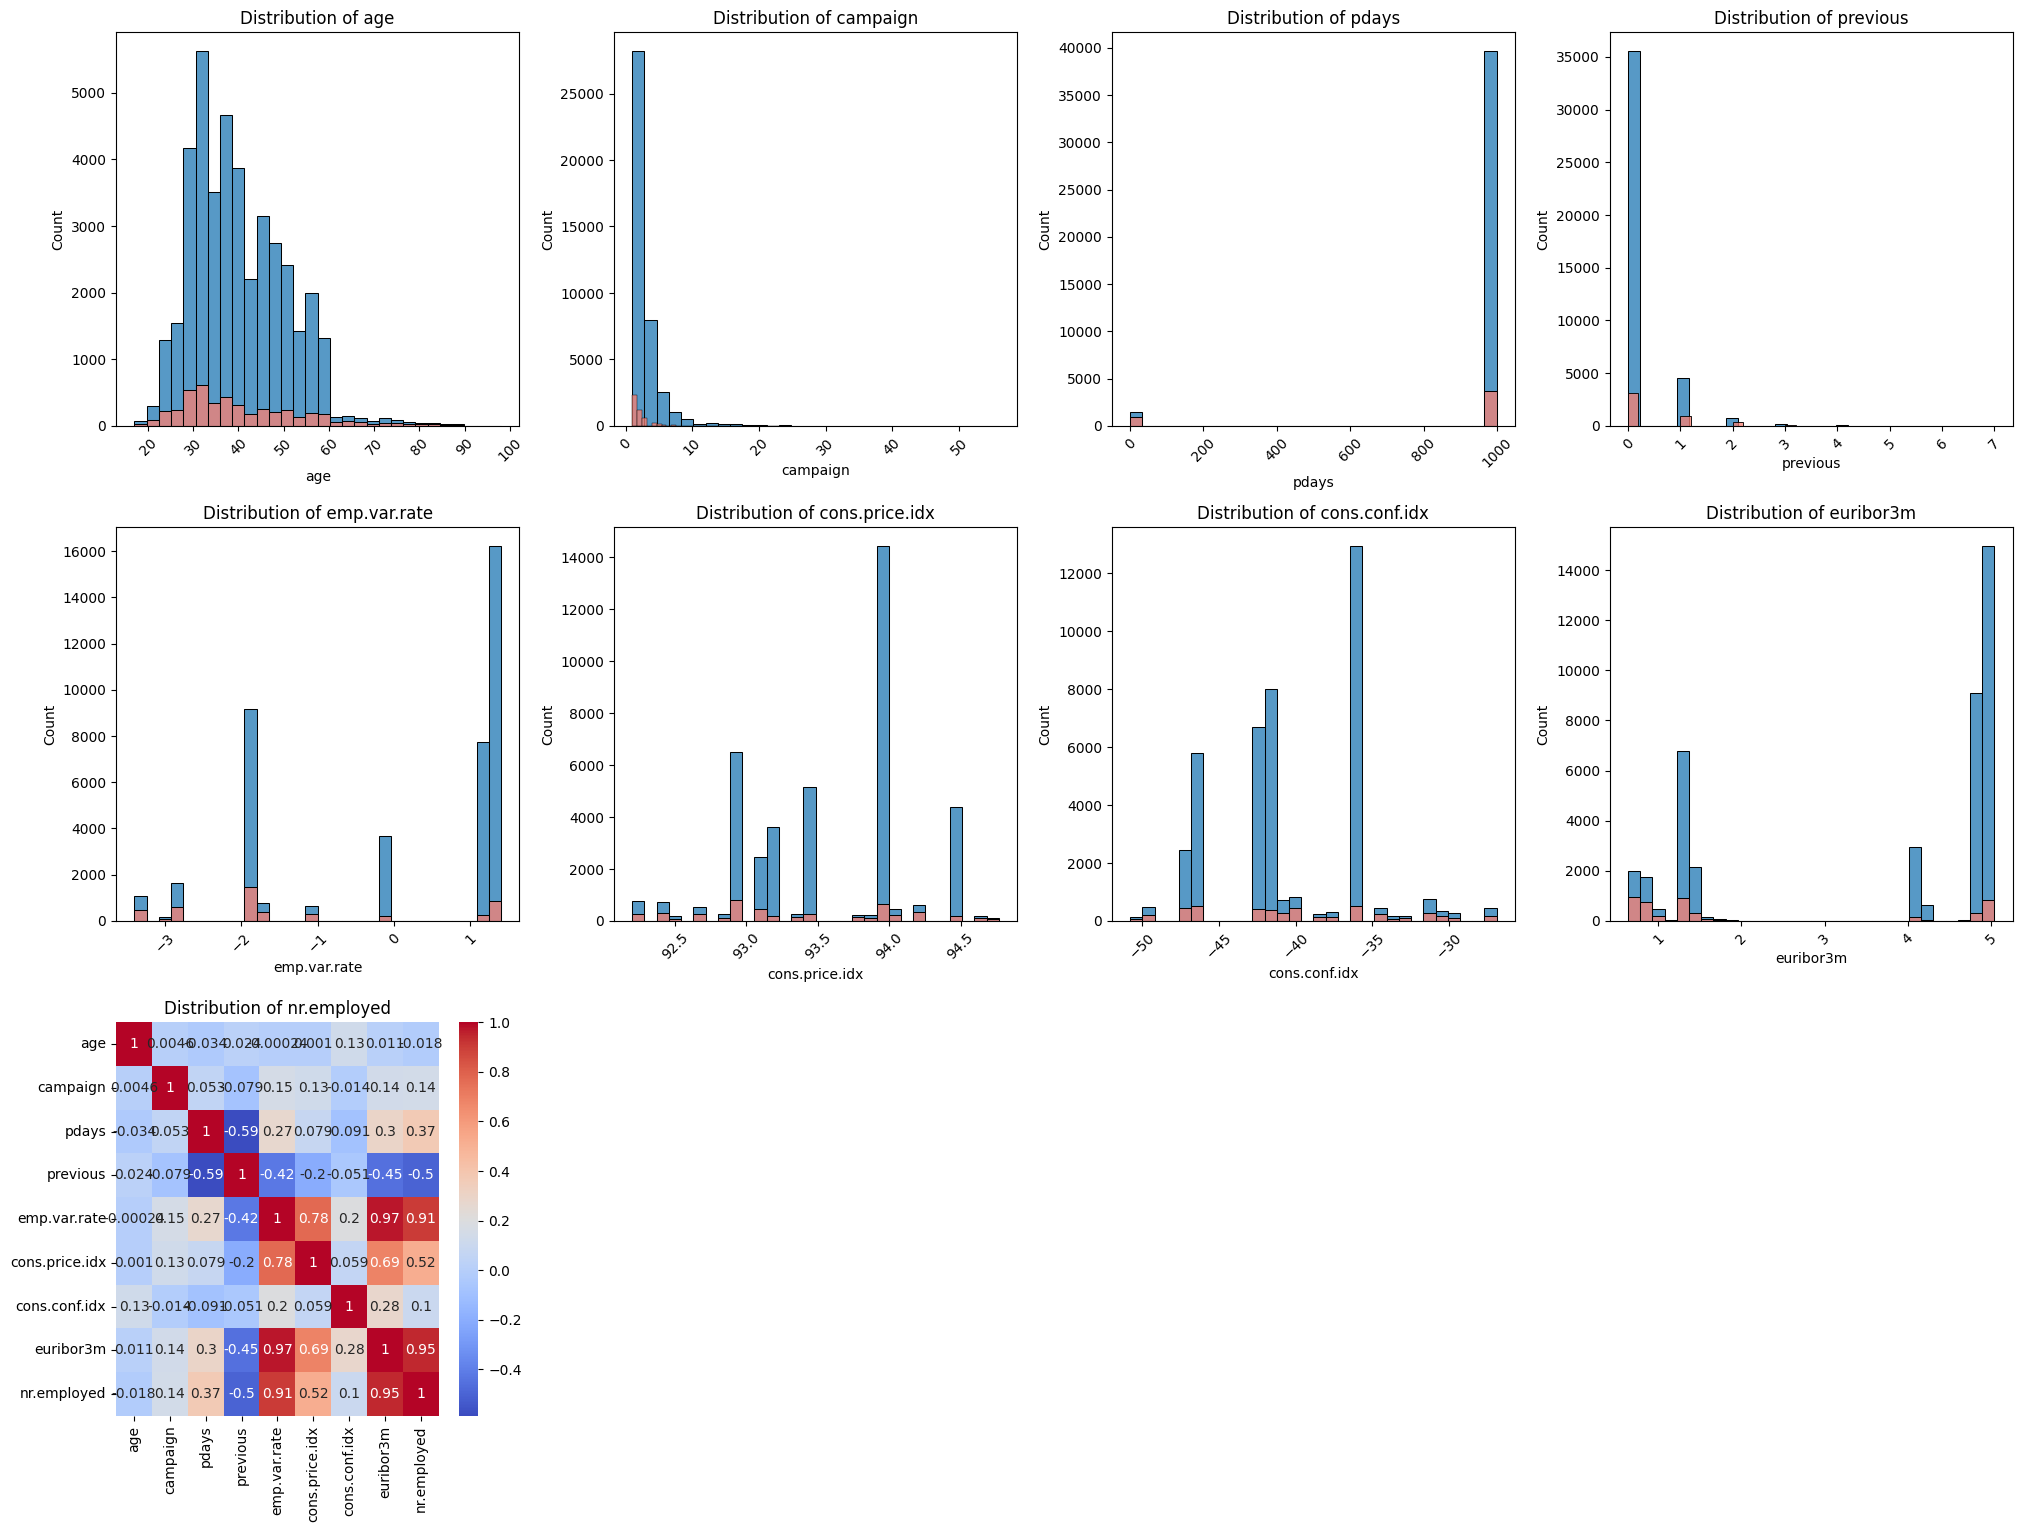

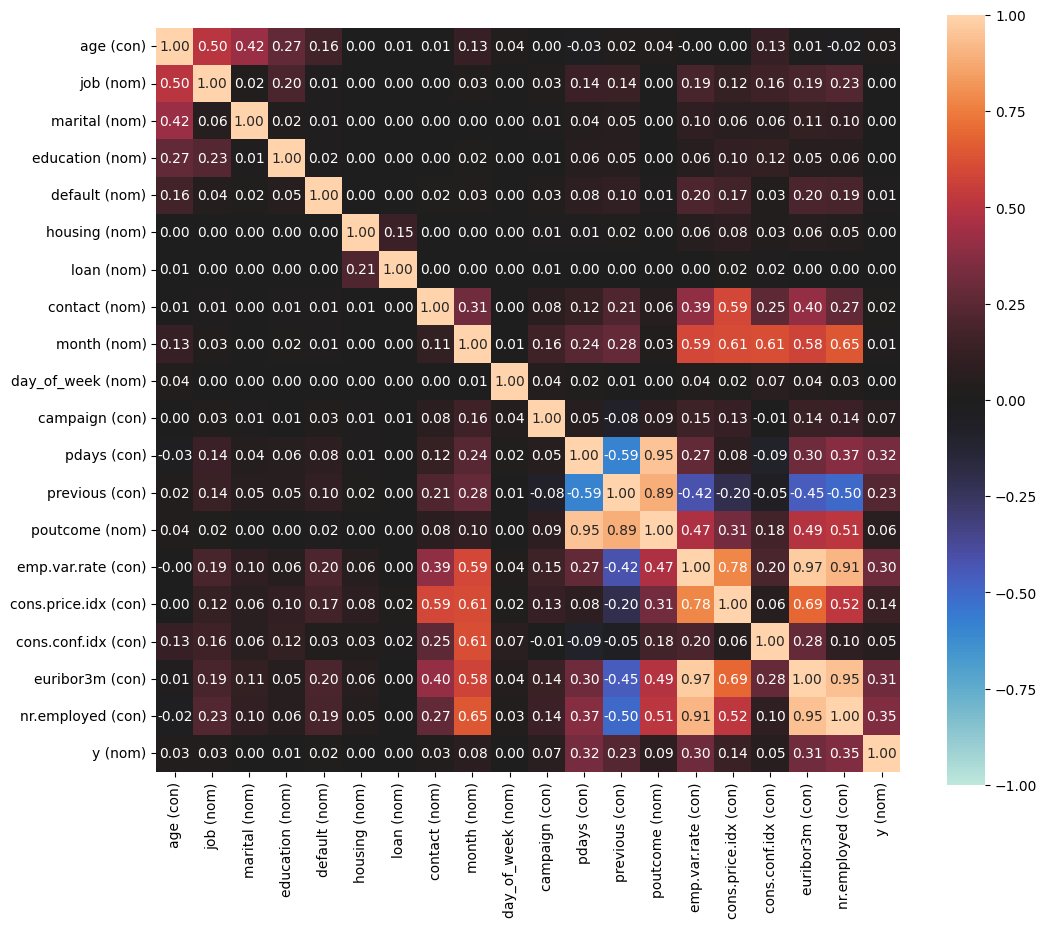

{'corr':                       age (con)  job (nom)  marital (nom)  education (nom)  \
 age (con)              1.000000   0.504836       0.418968         0.268620   
 job (nom)              0.504836   1.000000       0.024541         0.196624   
 marital (nom)          0.418968   0.055224       1.000000         0.024057   
 education (nom)        0.268620   0.229179       0.012460         1.000000   
 default (nom)          0.164995   0.043970       0.018929         0.053829   
 housing (nom)          0.001845   0.000483       0.000199         0.000445   
 loan (nom)             0.007359   0.000693       0.000077         0.000324   
 contact (nom)          0.006917   0.012679       0.004061         0.011781   
 month (nom)            0.126051   0.028297       0.002177         0.018037   
 day_of_week (nom)      0.037832   0.000679       0.000201         0.000701   
 campaign (con)         0.004622   0.029955       0.013071         0.007435   
 pdays (con)           -0.034381   0.141210 

In [8]:
#Define num df and cat df:
cat_df = df.select_dtypes(include=['object'])
num_df = df.select_dtypes(include=['float64', 'int64'])
#categorical relationships:
print('-'*80)
print('Categorical columns:')
plt.figure(figsize=(20, 15))
for i, cat in enumerate(cat_df.columns):
    plt.subplot(3, 4, i+1)
    sns.countplot(cat_df, x = cat)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {cat}')
    sns.countplot(cat_df[cat_df['y']=='yes'], 
                  x=cat,
                  color='salmon')


plt.tight_layout()


print('-'*80)
print('Numerical columns:')
plt.figure(figsize=(20, 15))

#To enable visualization on positive data:
y_num = df['y'].apply(lambda x: 1 if x=='yes' else 0)
num_df_plot = df.select_dtypes(include=['float64', 'int64'])
num_df_plot['y'] = y_num

for i, num in enumerate(num_df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(num_df, x = num, bins=30)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {num}')
    sns.histplot(num_df_plot[num_df_plot['y']==1], x=num, color='salmon', bins=30)
plt.tight_layout()

#pairplot for numerical values only:
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')

#Combined association:
print('-'*80)
print('Combined association plot. (Orange color highlights subscribed customers)')
from dython.nominal import associations
associations(df, nom_nom_assoc='theil', plot=True, figsize=(12,10), mark_columns=True)

SVM test:

# Randomized GridSearch for radial kernel with class balanced

In [9]:
X = df.drop('y', axis = 1)
y = df['y'].apply(lambda x: 1 if x =='yes' else 0)
#Train test split:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)
# Check the shape of the splits
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

#Define numerical and categorical columns:
cat_col = X.select_dtypes('object').columns
num_col = X.select_dtypes(['int64', 'float64']).columns

#Define the preprocessing steps:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_col),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_col)
])

#Let's try tuning the rbg kernel:
pca_svm_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', PCA()),
    ('pca_svm_grid', SVC(random_state=42, class_weight='balanced'))
])

#Define parameters:
svm_param = {
    'pca_svm_grid__C': loguniform(0.001, 1000),
    'pca_svm_grid__gamma': loguniform(1e-4, 1e1),
    'pca_svm_grid__kernel': ['rbf']
}

#5-fold CV:
pca_svm_grid = RandomizedSearchCV(pca_svm_pipe, param_distributions=svm_param, cv=3, n_jobs=-1, scoring='f1_macro', verbose=1, n_iter=50, random_state=41)

#fitting the model:
pca_svm_grid.fit(X_train, y_train)

#prediction:
pca_rbf_svm_pred = pca_svm_grid.predict(X_test)

#Get the number of features before PCA reduction:
X_transformed = pca_svm_grid.best_estimator_.named_steps['preprocessor'].transform(X_train)
num_of_feature_pos = X_transformed.shape[1]

# Now, access the number of components after the pipeline has been fitted
n_components_after_pca = pca_svm_grid.best_estimator_.named_steps['pca'].n_components_

#check results: 
print(f'Original number of features: {num_of_feature_pos}')
print(f'Number of features after PCA reduction: {n_components_after_pca}')
print('-'*80)
print(f'Best parameters: {pca_svm_grid.best_params_}')
print(f"Best train / test score: {pca_svm_grid.best_score_:.3f} / {pca_svm_grid.score(X_test, y_test):.3f}")
print('-'*80)
print('Classification report')
print(classification_report(y_test, pca_rbf_svm_pred))

Training data shape: (32940, 19)
Test data shape: (8236, 19)
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Original number of features: 62
Number of features after PCA reduction: 62
--------------------------------------------------------------------------------
Best parameters: {'pca_svm_grid__C': np.float64(992.728244444533), 'pca_svm_grid__gamma': np.float64(0.0025410210114933255), 'pca_svm_grid__kernel': 'rbf'}
Best train / test score: 0.693 / 0.712
--------------------------------------------------------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7308
           1       0.42      0.63      0.50       928

    accuracy                           0.86      8236
   macro avg       0.69      0.76      0.71      8236
weighted avg       0.89      0.86      0.87      8236



Use SMOTE method to resample positive outcome for data-rebalance:

In [10]:
from imblearn.over_sampling import SMOTE

#Reapply the pipeline with resampled data:
pca_svm_pipe_res = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('pca', PCA()),
    ('pca_svm_grid_res', SVC(
        class_weight='balanced',
        random_state=42
    ))
])

#Define parameters:
svm_param_res = {
    'pca_svm_grid__C': loguniform(0.001, 1000),
    'pca_svm_grid__gamma': loguniform(1e-4, 1e1),
    'pca_svm_grid__kernel': ['rbf']
}

#5-fold CV:
pca_svm_grid_res = RandomizedSearchCV(pca_svm_pipe, param_distributions=svm_param_res, cv=3, n_jobs=-1, scoring='f1_macro', verbose=1, n_iter=20, random_state=41)

#fitting the model:
pca_svm_grid_res.fit(X_train, y_train)

#prediction:
pca_rbf_svm_pred = pca_svm_grid_res.predict(X_test)

#check results: 
print('-'*80)
print(f'Best parameters: {pca_svm_grid_res.best_params_}')
print(f"Best train / test score: {pca_svm_grid_res.best_score_:.3f} / {pca_svm_grid_res.score(X_test, y_test):.3f}")
print('-'*80)
print('Classification report')
print(classification_report(y_test, pca_rbf_svm_pred))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
--------------------------------------------------------------------------------
Best parameters: {'pca_svm_grid__C': np.float64(992.728244444533), 'pca_svm_grid__gamma': np.float64(0.0025410210114933255), 'pca_svm_grid__kernel': 'rbf'}
Best train / test score: 0.693 / 0.712
--------------------------------------------------------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7308
           1       0.42      0.63      0.50       928

    accuracy                           0.86      8236
   macro avg       0.69      0.76      0.71      8236
weighted avg       0.89      0.86      0.87      8236



SVM with poly kernel:

In [12]:
svm_param = {
    'pca_svm_grid__C': loguniform(0.001, 1000),
    'pca_svm_grid__gamma': loguniform(1e-4, 1e1),
    'pca_svm_grid__kernel': ['poly']
}

#5-fold CV:
pca_svm_grid = RandomizedSearchCV(pca_svm_pipe, param_distributions=svm_param, cv=3, n_jobs=-1, scoring='f1_macro', verbose=1, n_iter=10, random_state=41)

#fitting the model:
pca_svm_grid.fit(X_train, y_train)

#prediction:
pca_rbf_svm_pred = pca_svm_grid.predict(X_test)

#Get the number of features before PCA reduction:
X_transformed = pca_svm_grid.best_estimator_.named_steps['preprocessor'].transform(X_train)
num_of_feature_pos = X_transformed.shape[1]

# Now, access the number of components after the pipeline has been fitted
n_components_after_pca = pca_svm_grid.best_estimator_.named_steps['pca'].n_components_

#check results: 
print(f'Original number of features: {num_of_feature_pos}')
print(f'Number of features after PCA reduction: {n_components_after_pca}')
print('-'*80)
print(f'Best parameters: {pca_svm_grid.best_params_}')
print(f"Best train / test score: {pca_svm_grid.best_score_:.3f} / {pca_svm_grid.score(X_test, y_test):.3f}")
print('-'*80)
print('Classification report')
print(classification_report(y_test, pca_rbf_svm_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Original number of features: 62
Number of features after PCA reduction: 62
--------------------------------------------------------------------------------
Best parameters: {'pca_svm_grid__C': np.float64(16.978347942610036), 'pca_svm_grid__gamma': np.float64(0.003744420979715947), 'pca_svm_grid__kernel': 'poly'}
Best train / test score: 0.699 / 0.714
--------------------------------------------------------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7308
           1       0.45      0.57      0.50       928

    accuracy                           0.87      8236
   macro avg       0.70      0.74      0.71      8236
weighted avg       0.89      0.87      0.88      8236



SVM with sigmoid kernel:

In [13]:
svm_param = {
    'pca_svm_grid__C': loguniform(0.001, 1000),
    'pca_svm_grid__gamma': loguniform(1e-4, 1e1),
    'pca_svm_grid__kernel': ['sigmoid']
}

#5-fold CV:
pca_svm_grid = RandomizedSearchCV(pca_svm_pipe, param_distributions=svm_param, cv=3, n_jobs=-1, scoring='f1_macro', verbose=1, n_iter=5, random_state=41)

#fitting the model:
pca_svm_grid.fit(X_train, y_train)

#prediction:
pca_rbf_svm_pred = pca_svm_grid.predict(X_test)

#Get the number of features before PCA reduction:
X_transformed = pca_svm_grid.best_estimator_.named_steps['preprocessor'].transform(X_train)
num_of_feature_pos = X_transformed.shape[1]

# Now, access the number of components after the pipeline has been fitted
n_components_after_pca = pca_svm_grid.best_estimator_.named_steps['pca'].n_components_

#check results: 
print(f'Original number of features: {num_of_feature_pos}')
print(f'Number of features after PCA reduction: {n_components_after_pca}')
print('-'*80)
print(f'Best parameters: {pca_svm_grid.best_params_}')
print(f"Best train / test score: {pca_svm_grid.best_score_:.3f} / {pca_svm_grid.score(X_test, y_test):.3f}")
print('-'*80)
print('Classification report')
print(classification_report(y_test, pca_rbf_svm_pred))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Original number of features: 62
Number of features after PCA reduction: 62
--------------------------------------------------------------------------------
Best parameters: {'pca_svm_grid__C': np.float64(0.03202887927292551), 'pca_svm_grid__gamma': np.float64(0.0001700118148305418), 'pca_svm_grid__kernel': 'sigmoid'}
Best train / test score: 0.613 / 0.660
--------------------------------------------------------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.92      0.95      0.94      7308
           1       0.47      0.32      0.38       928

    accuracy                           0.88      8236
   macro avg       0.70      0.64      0.66      8236
weighted avg       0.87      0.88      0.87      8236



Simple decision tree for baseline comparsion:

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('dt', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_param = {
    'dt__max_depth': [3, 5, 6, 7, 8, 9, None]}

dt_grid = GridSearchCV(dt_pipeline, param_grid=dt_param, cv=5, n_jobs=-1, scoring='f1_macro', verbose=1)

dt_grid.fit(X_train, y_train)
print('Best parameters:', dt_grid.best_params_)
print(f'Best training / testing 1-macro score: {dt_grid.best_score_:.3f} / {dt_grid.score(X_test, y_test):.3f}')
print('-'*80)
#Confusion matrix:
y_pred_dt = dt_grid.predict(X_test)
print(classification_report(y_test, y_pred_dt))

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best parameters: {'dt__max_depth': 7}
Best training / testing 1-macro score: 0.686 / 0.700
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.95      0.88      0.91      7308
           1       0.40      0.62      0.49       928

    accuracy                           0.85      8236
   macro avg       0.67      0.75      0.70      8236
weighted avg       0.89      0.85      0.87      8236



Previous XGBoost result:

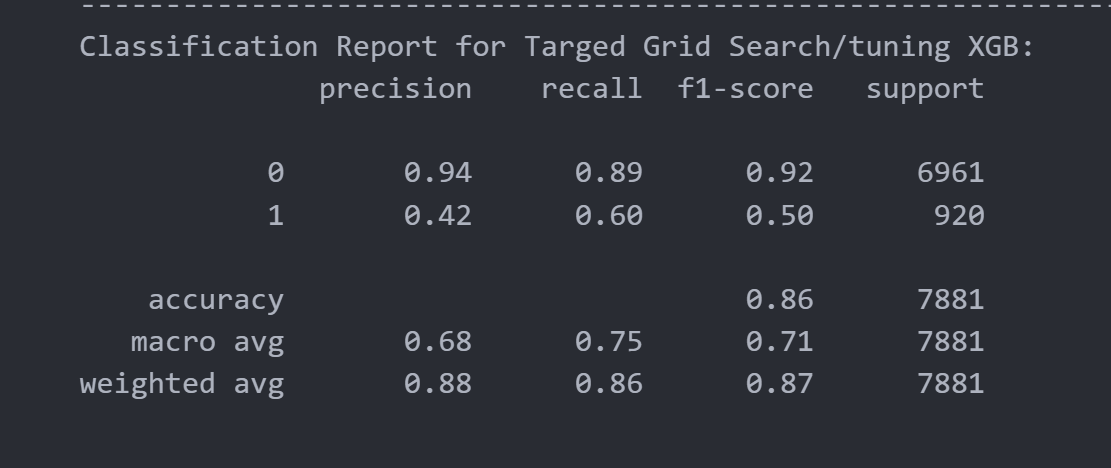

In [15]:
#insert image:
from IPython.display import Image
Image('xgb_result.png', width=500)

## Comparing SVM and the previous XGB results:

    Based on the results, SVM showed a higher recall (0.63) when compared to the XGB recall (0.60) while precision metric was the same for both models (0.42). The f1-marco score is same for both models, 0.71. Both class balancing techniques SMOTE and assign class weight were tested, and the results were identicial.

## Which algorithm is recommended to get more accurate results?

    While both models exhibited same level of specificity (precision of 0.42), it was the SVM model that has higher sensitivity in detecting the positive cases as indicated by 0.63 recall score. Ideally, the SVM model is a better choice for better detection of true positive values.

## Is it better for classification or regression scenarios?

    This has always been a classification scenario than regression because the target variable is a binary and discrete value.

## Do you agree with the recommendations? Why?

    I agree with the publications that were listed in this study. All of the citations listed below agreed that the performance of SVM is better than that of simple decision tree algorithm. The results shown here also confirms SVM outperforms the simple decision tree. However, the results from simple decision tree is surprisingly close to both XGB and SVM.

### Citations:

1) https://pmc.ncbi.nlm.nih.gov/articles/PMC5055373/
"Karimi-Alavijeh, F., Jalili, S., & Sadeghi, M. (2016). Predicting metabolic syndrome using decision tree and support vector machine methods. ARYA atherosclerosis, 12(3), 146–152."

2) "Guido, R., Ferrisi, S., Lofaro, D., & Conforti, D. (2024). An Overview on the Advancements of Support Vector Machine Models in Healthcare Applications: A Review. Information, 15(4), 235. https://doi.org/10.3390/info15040235"

3) Y. Xing, J. Wang, Z. Zhao and a. Gao, "Combination Data Mining Methods with New Medical Data to Predicting Outcome of Coronary Heart Disease," 2007 International Conference on Convergence Information Technology (ICCIT 2007), Gwangju, Korea (South), 2007, pp. 868-872, doi: 10.1109/ICCIT.2007.204.
https://www.researchgate.net/publication/232631972_Combination_Data_Mining_Methods_with_New_Medical_Data_to_Predicting_Outcome_of_Coronary_Heart_Disease

4) T., M., & Mukherji, D. (2013, April). A heart disease prediction model using SVM-decision trees-logistic regression (SDL). www.researchgate.net. https://www.researchgate.net/publication/273261237_A_Heart_Disease_Prediction_Model_using_SVM-Decision_Trees-Logistic_Regression_SDL
